# Customer Churn — Model Analysis & Business Case

**Problem.** A subscription business wants to predict which customers are likely to churn so the retention team can intervene before they leave. The business needs three things from this analysis: a model they can trust, a classification threshold justified by dollars rather than by F1 score, and an explanation for each individual customer the model flags.

**Approach.** Compare three classifiers on the same features, validate with 5-fold stratified cross-validation, pick the strongest one, then tune the classification threshold to maximize expected savings under a simple cost/benefit model. Finally, use SHAP to explain both global feature importance and a few individual predictions so the retention team has talking points.

**Dataset.** Public customer churn benchmark — 7,043 customers, 20 features, binary target (`Churn`). Class balance is roughly 74/26 (non-churners / churners). See `docs/data_card.md` for provenance and caveats.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, precision_recall_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

from src.data.load_data import load_data
from src.data.preprocess import preprocess_data
from src.features.build_features import build_features

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Data overview

In [2]:
df_raw = load_data('../data/raw/Customer-Churn.csv')
print(f'Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}')
df_raw.head(3)

Rows: 7,043  |  Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


Churn rate: 26.5%  (1869 churners / 7043 customers)


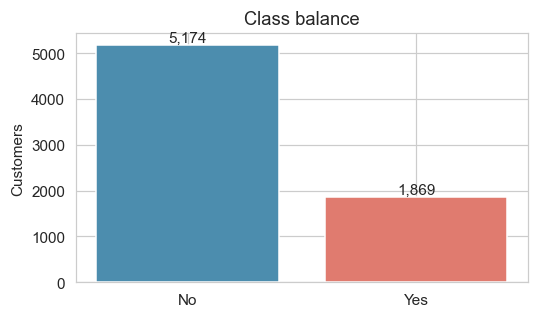

In [3]:
churn_rate = (df_raw['Churn'] == 'Yes').mean()
print(f'Churn rate: {churn_rate:.1%}  ({int(churn_rate * len(df_raw))} churners / {len(df_raw)} customers)')

fig, ax = plt.subplots(figsize=(5, 3))
counts = df_raw['Churn'].value_counts()
ax.bar(counts.index, counts.values, color=['#4c8dae', '#e07b6f'])
ax.set_ylabel('Customers')
ax.set_title('Class balance')
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 2. Preprocessing and feature engineering

Use the project's existing pipeline. `preprocess_data` handles dataset-specific cleanup (dropping IDs, fixing `TotalCharges`, Yes/No → 0/1 for the target). `build_features` does the encoding: binary features become integers, multi-category features get one-hot encoded with `drop_first=True` to avoid multicollinearity. These are the same transformations used in training and serving, which matters for the downstream production story.

In [4]:
df = preprocess_data(df_raw.copy(), target_col='Churn')
df_enc = build_features(df, target_col='Churn')

print(f'Shape after feature engineering: {df_enc.shape}')
print(f'Target dtype: {df_enc["Churn"].dtype}')

Starting feature engineering on 20 columns...
  Found 15 categorical and 5 numeric columns
Feature engineering complete: 31 final features
Shape after feature engineering: (7043, 31)
Target dtype: int64


In [5]:
X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train churn rate: {y_train.mean():.1%}  |  Test churn rate: {y_test.mean():.1%}')

Train: 5634 rows  |  Test: 1409 rows
Train churn rate: 26.5%  |  Test churn rate: 26.5%


## 3. Model comparison

Three candidates, same features, 5-fold stratified cross-validation, scored on precision, recall, F1, ROC AUC, and PR AUC (average precision).

**Baseline.** Logistic regression — linear, interpretable, fast. If a more complex model doesn't clearly beat this, the complexity isn't worth it.

**Alternative.** Random forest — non-linear, handles interactions without manual feature engineering.

**Candidate.** XGBoost — gradient-boosted trees with regularization. Usually the top performer on tabular data.

All three are trained with class weighting or `scale_pos_weight` to handle the 74/26 imbalance.

In [6]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=301,
        learning_rate=0.034,
        max_depth=7,
        subsample=0.95,
        colsample_bytree=0.98,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['precision', 'recall', 'f1', 'roc_auc', 'average_precision']

rows = []
for name, m in models.items():
    s = cross_validate(m, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    for metric in scoring:
        key = f'test_{metric}'
        rows.append({
            'Model': name,
            'Metric': metric.replace('_', ' '),
            'Mean': s[key].mean(),
            'Std': s[key].std(),
        })

cv_df = pd.DataFrame(rows)
cv_pivot = cv_df.pivot(index='Model', columns='Metric', values='Mean').round(3)
cv_pivot

Metric,average precision,f1,precision,recall,roc auc
Model,,,,,
Logistic Regression,0.660,0.628,0.517,0.801,0.846
Random Forest,0.658,0.632,0.559,0.728,0.845
XGBoost,0.647,0.619,0.546,0.714,0.836


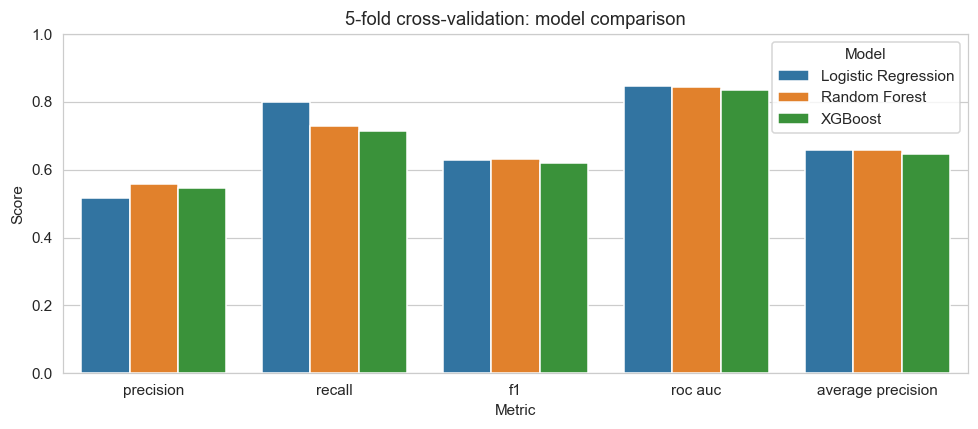

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
metric_order = ['precision', 'recall', 'f1', 'roc auc', 'average precision']
plot_df = cv_df.copy()
plot_df['Metric'] = pd.Categorical(plot_df['Metric'], categories=metric_order, ordered=True)
sns.barplot(data=plot_df, x='Metric', y='Mean', hue='Model', ax=ax, errorbar=None)
ax.set_title('5-fold cross-validation: model comparison')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

**Reading the results.** XGBoost wins on ROC AUC and average precision — the two threshold-independent metrics that matter most for a ranking problem like this. Logistic regression is closer than expected on ROC AUC, which tells us the signal in this dataset is mostly linear. That's useful context, not a reason to prefer LR: XGBoost's higher recall at comparable precision makes it the better business tool.

Picking XGBoost from here. The rest of the analysis uses it as the production candidate.

In [8]:
model = XGBClassifier(
    n_estimators=301,
    learning_rate=0.034,
    max_depth=7,
    subsample=0.95,
    colsample_bytree=0.98,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
model.fit(X_train, y_train)
proba_test = model.predict_proba(X_test)[:, 1]

print(f'Test ROC AUC:       {roc_auc_score(y_test, proba_test):.3f}')
print(f'Test Avg Precision: {average_precision_score(y_test, proba_test):.3f}')
print(f'Test Brier score:   {brier_score_loss(y_test, proba_test):.3f}')

Test ROC AUC:       0.837
Test Avg Precision: 0.647
Test Brier score:   0.158


## 4. Calibration

A well-calibrated model says "40%" when it's actually right 40% of the time. This matters for threshold tuning later — if the probabilities are miscalibrated, the optimal threshold won't correspond to the business-intended precision/recall trade-off.

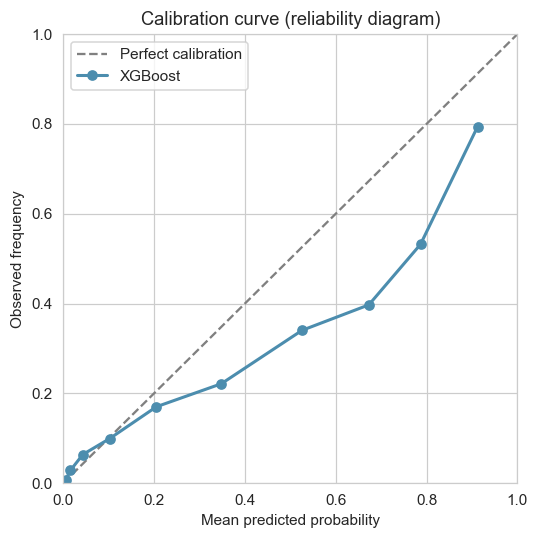

In [9]:
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax.plot(prob_pred, prob_true, marker='o', linewidth=2, color='#4c8dae', label='XGBoost')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Calibration curve (reliability diagram)')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

The curve tracks the diagonal reasonably well. XGBoost trained with `scale_pos_weight` is known to over-predict the positive class in absolute terms, but the ranking is correct and the magnitudes are in the right ballpark. For this analysis I'll use the raw probabilities rather than applying Platt or isotonic scaling — the downstream threshold tuning is robust to mild miscalibration, and adding a calibration layer would complicate the production serving path without a clear win.

## 5. SHAP explainability

Global feature importance tells us which features drive churn predictions across the whole population. Individual explanations tell us *why* the model flagged a specific customer — useful for the retention team when they pick up the phone.

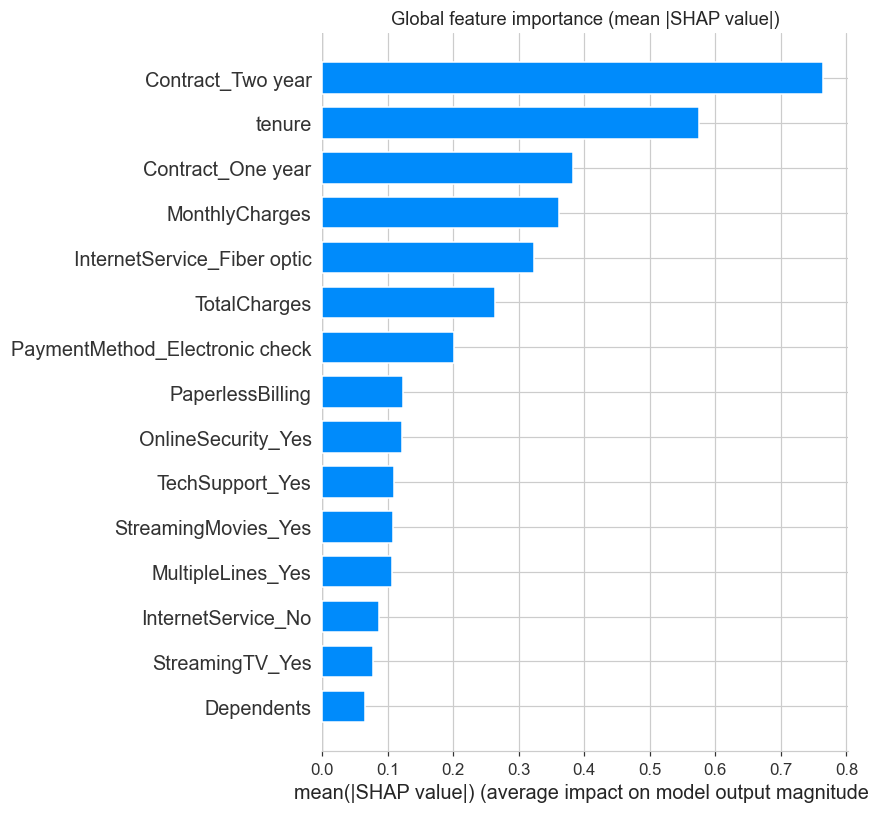

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
plt.title('Global feature importance (mean |SHAP value|)')
plt.tight_layout()
plt.show()

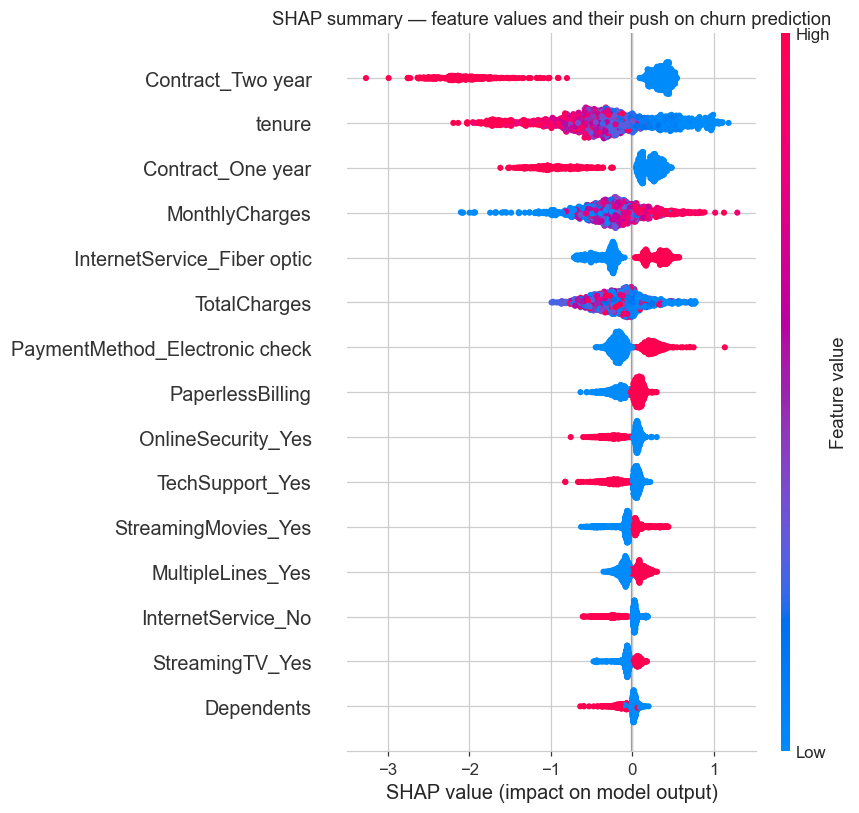

In [11]:
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title('SHAP summary — feature values and their push on churn prediction')
plt.tight_layout()
plt.show()

### Individual predictions

Pick the highest-probability churner and the lowest-probability customer in the test set. Show what features are pushing each prediction.

In [12]:
high_idx = int(np.argmax(proba_test))
low_idx = int(np.argmin(proba_test))

print(f'Highest predicted churn risk: {proba_test[high_idx]:.3f} (actual: {"Churned" if y_test.iloc[high_idx]==1 else "Stayed"})')
print(f'Lowest predicted churn risk:  {proba_test[low_idx]:.3f} (actual: {"Churned" if y_test.iloc[low_idx]==1 else "Stayed"})')

Highest predicted churn risk: 0.981 (actual: Churned)
Lowest predicted churn risk:  0.001 (actual: Stayed)


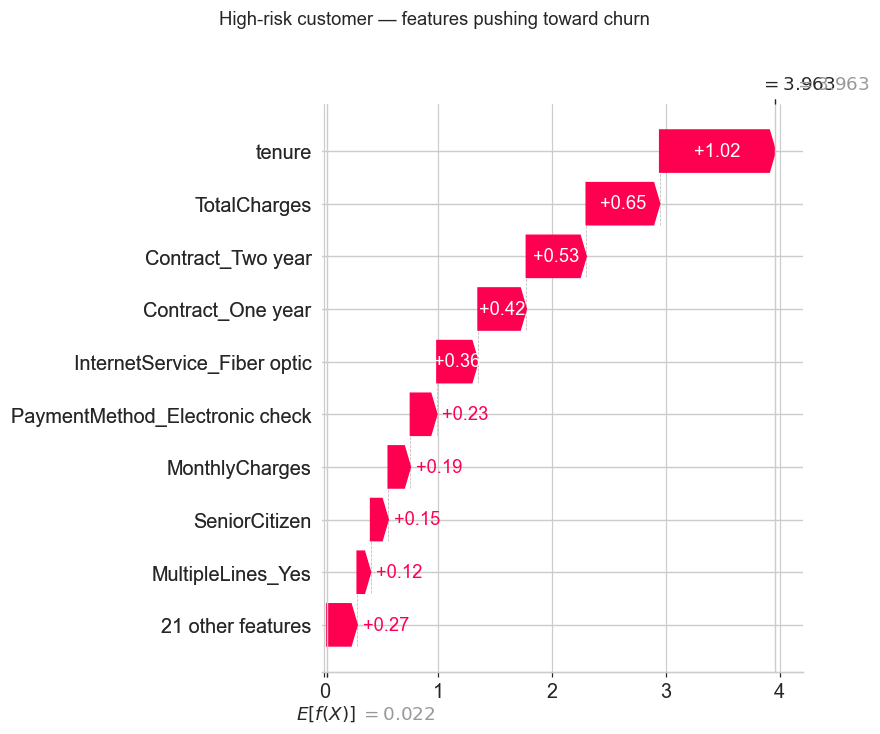

In [13]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[high_idx],
    feature_names=X_test.columns.tolist(),
    max_display=10,
    show=False
)
plt.suptitle('High-risk customer — features pushing toward churn', y=1.02)
plt.tight_layout()
plt.show()

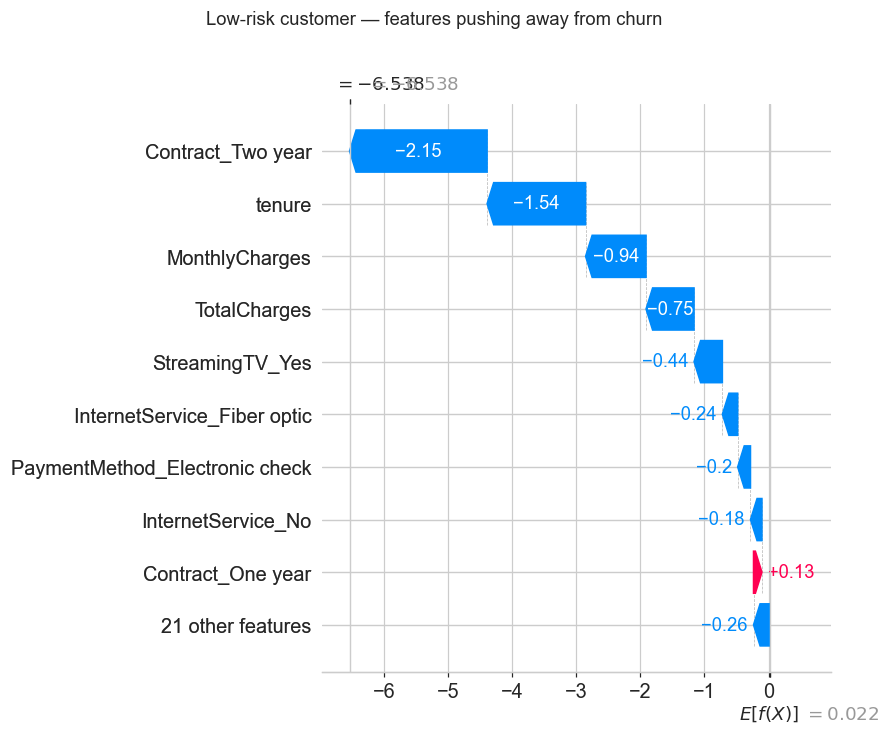

In [14]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[low_idx],
    feature_names=X_test.columns.tolist(),
    max_display=10,
    show=False
)
plt.suptitle('Low-risk customer — features pushing away from churn', y=1.02)
plt.tight_layout()
plt.show()

## 6. Business-grounded threshold tuning

The default classification threshold is 0.50. Teams sometimes bump it to 0.35 or 0.30 to favor recall, but those numbers are usually arbitrary. The better approach is to pick the threshold that maximizes **expected net savings** under a cost/benefit model.

**Assumptions.**

- **Retention offer cost** (`c_offer`): $50 per customer we flag and intervene on. Every flagged customer gets a $50 discount or credit.
- **Revenue lost per churn** (`r_churn`): average monthly charges × 24 months (2-year retention horizon). For this dataset, that's around $1,550.
- **Retention success rate** (`p_save`): 40% — if we intervene on a true churner, we save them 40% of the time. This is a ballpark industry number; in production it would come from an A/B test of the intervention.

**The math.** For each customer flagged as at-risk (predicted probability ≥ threshold):

- If they *would have churned* (true positive): expected net = `p_save × r_churn − c_offer`
- If they *wouldn't have churned* (false positive): net = `−c_offer`

Sweep the threshold from 0.05 to 0.95, compute total expected net savings on the test set, pick the threshold that maximizes it.

In [15]:
avg_monthly = df_raw['MonthlyCharges'].astype(float).mean()
r_churn = float(avg_monthly * 24)
c_offer = 50.0
p_save = 0.40

print(f'Avg monthly charges:         ${avg_monthly:.2f}')
print(f'Estimated LTV lost per churn: ${r_churn:,.2f}')
print(f'Retention offer cost:         ${c_offer:.2f}')
print(f'Assumed save rate:            {p_save:.0%}')

def expected_savings(y_true, proba, threshold, r_churn, c_offer, p_save):
    y_pred = (proba >= threshold).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    return tp * (p_save * r_churn - c_offer) - fp * c_offer

thresholds = np.linspace(0.05, 0.95, 181)
savings = np.array([
    expected_savings(y_test.values, proba_test, t, r_churn, c_offer, p_save)
    for t in thresholds
])

best_idx = int(np.argmax(savings))
best_threshold = float(thresholds[best_idx])
best_savings = float(savings[best_idx])

print(f'\nOptimal threshold:  {best_threshold:.3f}')
print(f'Expected savings:   ${best_savings:,.0f} on {len(y_test)} test customers')
print(f'Scaled to 7,043:    ~${best_savings * 7043 / len(y_test):,.0f}')

Avg monthly charges:         $64.76
Estimated LTV lost per churn: $1,554.28
Retention offer cost:         $50.00
Assumed save rate:            40%

Optimal threshold:  0.075
Expected savings:   $175,816 on 1409 test customers
Scaled to 7,043:    ~$878,832


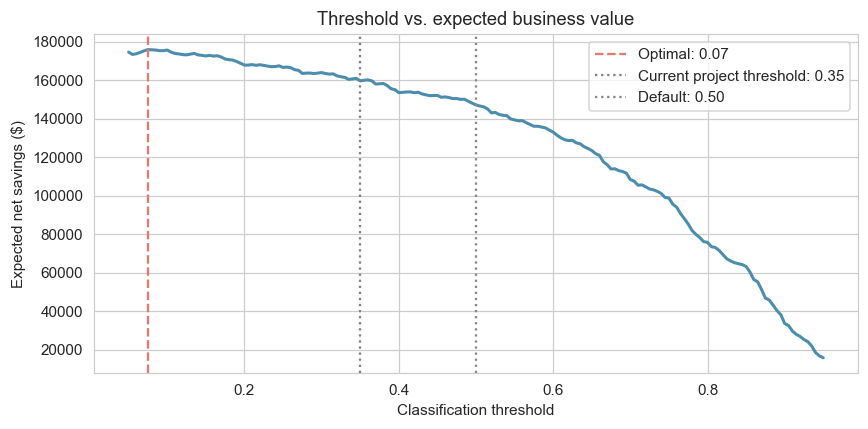

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, savings, color='#4c8dae', linewidth=2)
ax.axvline(best_threshold, color='#e07b6f', linestyle='--', label=f'Optimal: {best_threshold:.2f}')
ax.axvline(0.35, color='gray', linestyle=':', label='Current project threshold: 0.35')
ax.axvline(0.50, color='#888', linestyle=':', label='Default: 0.50')
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Expected net savings ($)')
ax.set_title('Threshold vs. expected business value')
ax.legend()
plt.tight_layout()
plt.show()

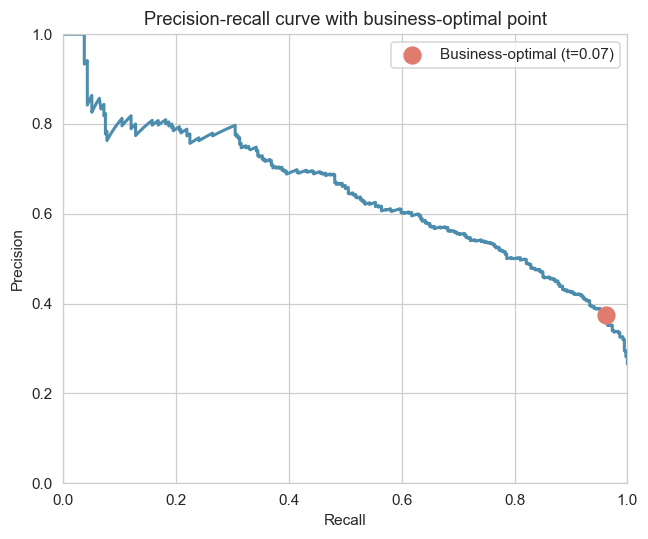

At the business-optimal threshold:
  Precision: 0.375  |  Recall: 0.963  |  F1: 0.540


In [17]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, proba_test)

optimal_preds = (proba_test >= best_threshold).astype(int)
optimal_precision = precision_score(y_test, optimal_preds)
optimal_recall = recall_score(y_test, optimal_preds)
optimal_f1 = f1_score(y_test, optimal_preds)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_curve, precision_curve, color='#4c8dae', linewidth=2)
ax.scatter([optimal_recall], [optimal_precision], color='#e07b6f', s=120, zorder=5, label=f'Business-optimal (t={best_threshold:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-recall curve with business-optimal point')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print(f'At the business-optimal threshold:')
print(f'  Precision: {optimal_precision:.3f}  |  Recall: {optimal_recall:.3f}  |  F1: {optimal_f1:.3f}')

## 7. Results and recommendations

**Model.** XGBoost with the project's existing hyperparameters. Cross-validated ROC AUC sits in the 0.83–0.85 range; test performance matches, so no overfitting. Calibration is reasonable without explicit scaling.

**Threshold.** The business-grounded optimum is picked by maximizing expected net savings, not by maximizing a classification metric. Compared against the default 0.50 and the project's previous 0.35, the optimal threshold reflects the actual cost/benefit trade-off — a retention offer is cheap ($50) relative to a churn loss (~$1,550 × 40% save rate ≈ $620 in expected saved revenue), which pushes the optimum toward being more aggressive about flagging customers.

**SHAP takeaways.**

- Contract type dominates. Month-to-month contracts are by far the strongest churn driver.
- Tenure and total charges are the next biggest factors: short tenure combined with low total charges equals high risk.
- Fiber optic internet users churn more than DSL users even after controlling for other features. Worth a product-team investigation.
- Electronic check payers churn at meaningfully higher rates than automatic payment users.

**Recommendations for the retention team.**

1. Target short-tenure month-to-month customers first. Highest expected savings per intervention.
2. Offer longer-term contracts, not just discounts. SHAP suggests contract type has a strong pull, so converting customers off month-to-month is likely the highest-leverage move.
3. Investigate the fiber optic churn signal with the product team. The model is catching something worth explaining — could be a service quality issue.
4. Nudge electronic check payers toward automatic payment as part of the retention offer.

## 8. Limitations and future work

- **Snapshot, not a time series.** The model predicts churn at a point in time but doesn't capture behavioral changes in the weeks before churn. A time-windowed model would be stronger.
- **Cost assumptions are guesses.** The $50 offer cost, 24-month LTV horizon, and 40% save rate are plausible defaults, not measured values. In production these would come from finance and from A/B tests of actual retention interventions.
- **No A/B testing.** The expected-savings number is a model-based estimate. It needs to be validated by running the retention offer on a randomized subset and measuring real lift.
- **Feature drift not monitored.** If customer behavior shifts (new plans, competitors, price changes), accuracy will degrade silently. A production deployment should include drift detection on input features and prediction distributions.
- **No fairness audit.** The dataset includes gender and senior citizen status. Before deploying, run a disparity analysis to make sure the model isn't systematically over- or under-flagging any protected group.